In [41]:
import torch
import matplotlib.pyplot as plt
import numpy as np
x=torch.arange(4.0,dtype=torch.float32,requires_grad=True)

print(x.grad) #None by default

y=2*x@x
print(y)

y.backward()
print(x.grad)

x.grad==4*x 

#reset gradient
x.grad.zero_()
y=x.sum()
y.backward()
print(x.grad)

#backward for non scalar variables

x.grad.zero_()
y=x*x
y.sum().backward()
print(x.grad)

None
tensor(28., grad_fn=<DotBackward0>)
tensor([ 0.,  4.,  8., 12.])
tensor([1., 1., 1., 1.])
tensor([0., 2., 4., 6.])


# 2.5.3 Detaching Computation

In [42]:
x.grad.zero_()
y=x*x
u=y.detach()
z=u*x

z.sum().backward()
print(x.grad==u)

x.grad.zero_()
y.sum().backward()
print(x.grad)




tensor([True, True, True, True])
tensor([0., 2., 4., 6.])


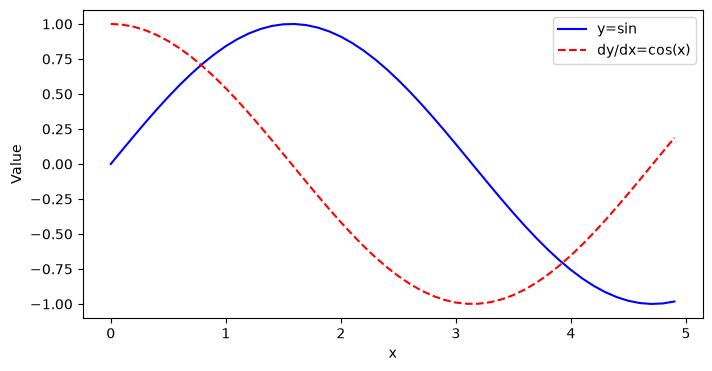

In [ ]:
x=torch.arange(0,5,step=0.1,dtype=torch.float32,requires_grad=True)
y=torch.sin(x)
y.sum().backward()

x_np=x.detach().numpy()
y_np=y.detach().numpy()
grad_np=x.grad.numpy()

plt.figure(figsize=(8,4))
plt.plot(x_np,y_np,label="y=sin",color="blue")
plt.plot(x_np,grad_np,label="dy/dx=cos(x)",color="red",linestyle="--")
plt.xlabel("x")
plt.ylabel("Value")
plt.legend()
plt.show()

